# Évaluation Finale et Optimisation du Modèle

Ce notebook présente l'évaluation finale du modèle sur le jeu de test. Il couvre l'ensemble des métriques quantitatives, les visualisations de performance (ROC, PR), l'analyse des probabilités prédites et l'optimisation du seuil de décision.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, confusion_matrix, 
                             accuracy_score, f1_score, roc_curve, auc, 
                             precision_recall_curve, average_precision_score)
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")


## 1. Chargement des Données et du Modèle Final


In [25]:
try:
    test_df = pd.read_csv('../data/processed/test.csv')
    X_test = test_df.drop(columns=['is_phishing'])
    y_test = test_df['is_phishing']
    
    # Reconstitution des colonnes attendues par le pipeline
    age_cols = [c for c in X_test.columns if c.startswith('domain_age_category_')]
    if age_cols:
        X_test['domain_age_category'] = X_test[age_cols].idxmax(axis=1).str.replace('domain_age_category_', '')
        X_test = X_test.drop(columns=age_cols)
        
    if 'country' not in X_test.columns:
        X_test['country'] = 'UNKNOWN'
    
    model = joblib.load('../models/final_model.joblib')
    print("Modèle et données de test chargés avec succès.")
    
except FileNotFoundError:
    print("Erreur : Veuillez vérifier la présence des fichiers dans data/processed/ et models/.")

# Calcul des probabilités et des prédictions par défaut
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)


Modèle et données de test chargés avec succès.


## 2. Métriques Quantitatives et Matrice de Confusion (Seuil 0.5)

Évaluation standard du modèle avec le seuil par défaut de 0.5.


=== Métriques Quantitatives (Seuil 0.5) ===
Accuracy  : 0.981
Precision : 1.000
Recall    : 0.893
F1-Score  : 0.944


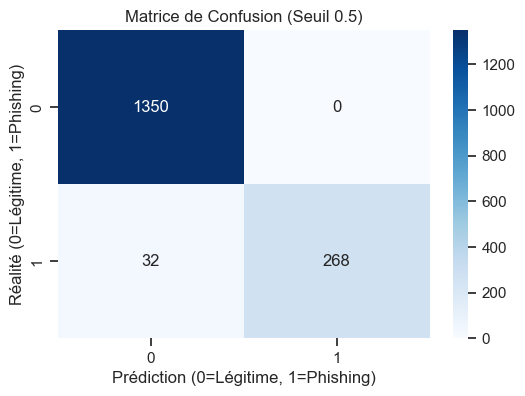

In [26]:
print("=== Métriques Quantitatives (Seuil 0.5) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_default):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_default, zero_division=0):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_default, zero_division=0):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_default, zero_division=0):.3f}")

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion (Seuil 0.5)")
plt.xlabel("Prédiction (0=Légitime, 1=Phishing)")
plt.ylabel("Réalité (0=Légitime, 1=Phishing)")
plt.show()


> **Interprétation** : 
> - **Vrais Positifs (TP)** : Nombre de sites de phishing correctement bloqués.
> - **Vrais Négatifs (TN)** : Nombre de sites légitimes correctement autorisés.
> - **Faux Positifs (FP)** : Sites légitimes bloqués par erreur (friction utilisateur).
> - **Faux Négatifs (FN)** : Sites de phishing non détectés (danger critique).


## 3. Visualisations de Performance Globale

### 3.1 Courbes ROC et Precision-Recall

La courbe **Precision-Recall (PR)** est particulièrement importante ici car notre jeu de données est déséquilibré (le phishing est minoritaire).


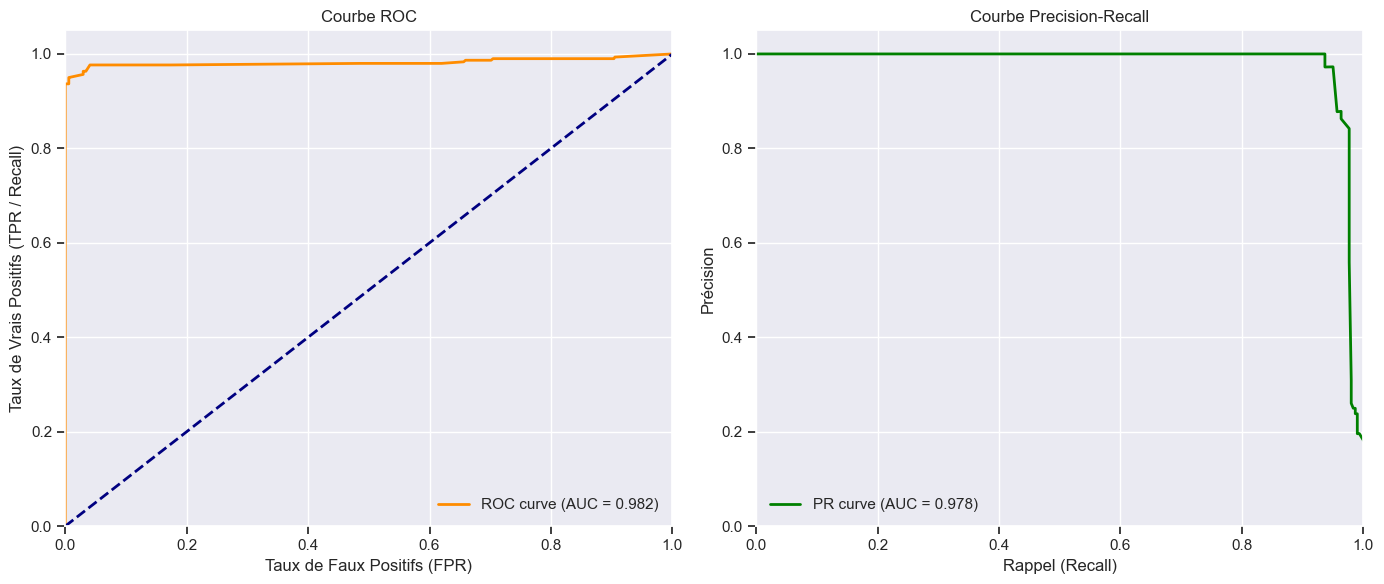

In [27]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Courbe ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR / Recall)')
axes[0].set_title('Courbe ROC')
axes[0].legend(loc="lower right")

# Courbe Precision-Recall
axes[1].plot(recall_vals, precision_vals, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Rappel (Recall)')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


### 3.2 Analyse de la Distribution des Probabilités Prédites

Cette visualisation montre la capacité du modèle à séparer nettement les classes avant l'application d'un seuil.


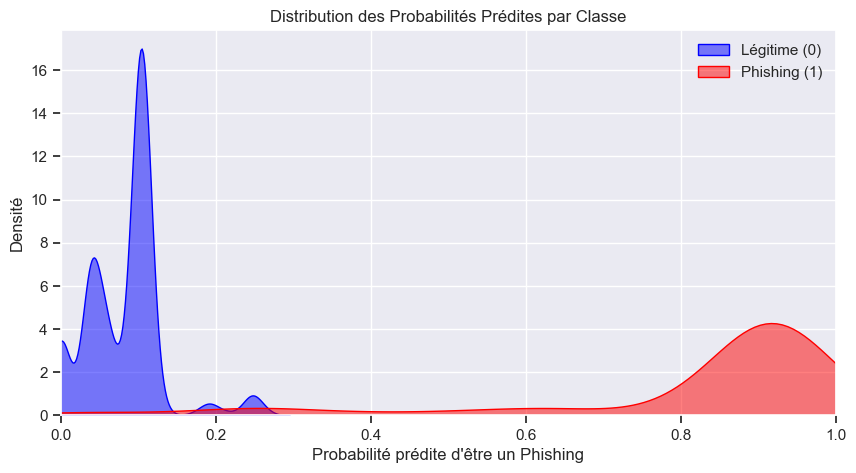

In [28]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_proba[y_test == 0], label='Légitime (0)', fill=True, color='blue', alpha=0.5)
sns.kdeplot(y_proba[y_test == 1], label='Phishing (1)', fill=True, color='red', alpha=0.5)
plt.title('Distribution des Probabilités Prédites par Classe')
plt.xlabel('Probabilité prédite d\'être un Phishing')
plt.ylabel('Densité')
plt.legend()
plt.xlim(0, 1)
plt.show()


## 4. Optimisation du Seuil de Décision selon les Coûts Métiers

L'évaluation utilise une matrice de coût asymétrique pour refléter l'impact réel : un Faux Négatif (fraude non détectée) coûte beaucoup plus cher qu'un Faux Positif (friction utilisateur).


In [29]:
COUT_FN = 1000 
COUT_FP = 50   

seuils = np.arange(0.1, 0.91, 0.01)
precisions, recalls, couts = [], [], []

for seuil in seuils:
    y_pred_seuil = (y_proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_seuil).ravel()
    
    precisions.append(precision_score(y_test, y_pred_seuil, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_seuil, zero_division=0))
    couts.append((fn * COUT_FN) + (fp * COUT_FP))

index_optimal = np.argmin(couts)
seuil_optimal = seuils[index_optimal]
cout_min = couts[index_optimal]

print(f"Seuil optimal identifié : {seuil_optimal:.2f}")
print(f"Coût minimum associé : {cout_min}")


Seuil optimal identifié : 0.19
Coût minimum associé : 10100


### 4.1 Courbe Seuil : Évolution des Performances et du Coût

Visualisation croisée de la Precision, du Recall et du Coût total en fonction du seuil de décision.


In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Seuil de Décision')
ax1.set_ylabel('Scores (Precision / Recall)', color=color)
ax1.plot(seuils, precisions, label='Precision', color='blue', linestyle='--')
ax1.plot(seuils, recalls, label='Recall', color='green', linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='center left')
ax1.set_xlim(0.1, 0.9)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coût Métier Total', color=color)
ax2.plot(seuils, couts, label='Coût Financier', color='red', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.axvline(x=seuil_optimal, color='black', linestyle=':', label=f'Seuil optimal ({seuil_optimal:.2f})')
ax2.legend(loc='center right')

plt.title('Compromis Precision/Recall et Optimisation des Coûts')
fig.tight_layout()
plt.show()


### 4.2 Comparaison des Seuils et Validation des Objectifs


In [ ]:
y_pred_optimal = (y_proba >= seuil_optimal).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0]) # cm est la matrice au seuil 0.5 (calculée plus haut)
cout_default = (cm[1,0]*COUT_FN) + (cm[0,1]*COUT_FP)
axes[0].set_title(f"Matrice avec Seuil par Défaut (0.50)\nCoût Total: {cout_default}")
axes[0].set_xlabel("Prédiction")
axes[0].set_ylabel("Réalité")

sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f"Matrice avec Seuil Optimal ({seuil_optimal:.2f})\nCoût Total: {cout_min}")
axes[1].set_xlabel("Prédiction")
axes[1].set_ylabel("Réalité")

plt.show()

print("=== Performances Finales avec le Seuil Optimal ===")
print(f"Recall (Cible >= 0.90) : {recall_score(y_test, y_pred_optimal):.3f}")
print(f"Precision (Cible >= 0.65) : {precision_score(y_test, y_pred_optimal):.3f}")
print(f"F1-Score (Cible >= 0.80) : {f1_score(y_test, y_pred_optimal):.3f}")
